In [2]:
# 1. Install ONLY the core tools (removed the heavy [extra] baggage)
!pip install stable-baselines3 gymnasium

# 2. Import the libraries safely
import numpy as np
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy

# 3. Define our custom tool to simulate chaotic reactor sensors
class NoisyObservationWrapper(gym.ObservationWrapper):
    def __init__(self, env, noise_level=0.15):
        super().__init__(env)
        self.noise_level = noise_level

    def observation(self, obs):
        noise = np.random.normal(0, self.noise_level, size=obs.shape)
        return obs + noise

print("Cell 1 complete: Core tools installed and Wrapper defined!")

  Using cached stable_baselines3-2.8.0-py3-none-any.whl.metadata (4.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 46.2 MB/s eta 0:00:00
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 1.3.0
    Uninstalling gymnasium-1.3.0:
      Successfully uninstalled gymnasium-1.3.0
Cell 1 complete: Core tools installed and Wrapper defined!


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
print("Starting Clean Agent Training. This takes about 30-60 seconds...")

# 1. Create the perfect environment
env_clean = gym.make("CartPole-v1")

# 2. Build and train the AI
model_clean = PPO("MlpPolicy", env_clean, verbose=0)
model_clean.learn(total_timesteps=25000)

print("Cell 2 complete: Clean Agent is trained!")

Starting Clean Agent Training. This takes about 30-60 seconds...
Cell 2 complete: Clean Agent is trained!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [4]:
print("Starting Noisy Agent Training. This takes about 30-60 seconds...")

# 1. Create the base environment, then wrap it in noise
env_base = gym.make("CartPole-v1")
env_noisy = NoisyObservationWrapper(env_base, noise_level=0.15)

# 2. Build and train the AI in this chaotic setting
model_noisy = PPO("MlpPolicy", env_noisy, verbose=0)
model_noisy.learn(total_timesteps=25000)

print("Cell 3 complete: Noisy Agent is trained!")

Starting Noisy Agent Training. This takes about 30-60 seconds...
Cell 3 complete: Noisy Agent is trained!


In [5]:
print("--- RUNNING FINAL EVALUATION ---")

# Test 1: Clean model in clean environment (Should be perfect, ~500)
mean_reward_clean, _ = evaluate_policy(model_clean, env_clean, n_eval_episodes=10)
print(f"1. Clean Model on Clean Env: {mean_reward_clean} / 500.0")

# Test 2: Clean model in noisy environment (Should fail/drop significantly)
mean_reward_failed, _ = evaluate_policy(model_clean, env_noisy, n_eval_episodes=10)
print(f"2. Clean Model on Noisy Env: {mean_reward_failed} / 500.0")

# Test 3: Noisy-Trained model in noisy environment (Should recover performance)
mean_reward_robust, _ = evaluate_policy(model_noisy, env_noisy, n_eval_episodes=10)
print(f"3. Noisy-Trained Model on Noisy Env: {mean_reward_robust} / 500.0")

--- RUNNING FINAL EVALUATION ---


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


1. Clean Model on Clean Env: 500.0 / 500.0
2. Clean Model on Noisy Env: 500.0 / 500.0
3. Noisy-Trained Model on Noisy Env: 390.4 / 500.0


Gathering data for the graph. This will run 60 quick simulations...
Data gathered! Drawing the graph...



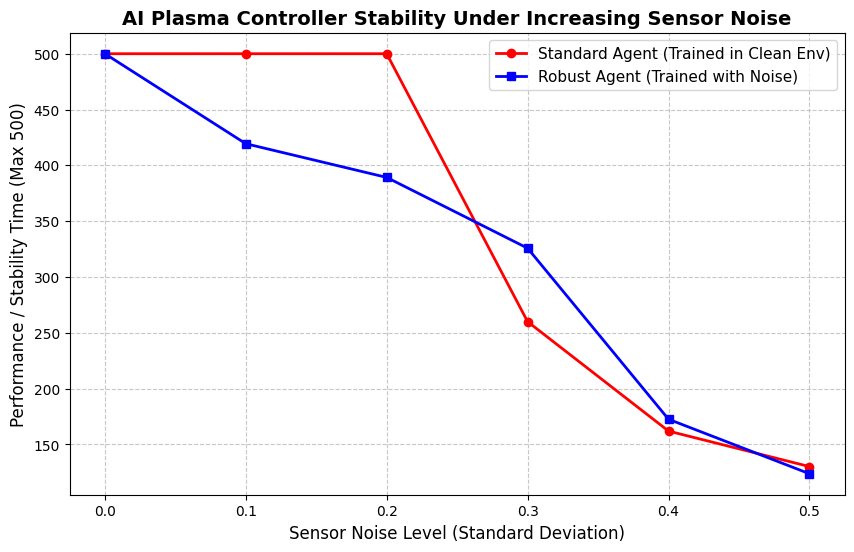

In [6]:
import matplotlib.pyplot as plt

print("Gathering data for the graph. This will run 60 quick simulations...")

noise_levels = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
clean_agent_scores = []
robust_agent_scores = []

for noise in noise_levels:
    # Create a temporary environment with this specific level of noise
    test_env = NoisyObservationWrapper(gym.make("CartPole-v1"), noise_level=noise)

    # Test how the standard AI handles it
    score_clean, _ = evaluate_policy(model_clean, test_env, n_eval_episodes=5)
    clean_agent_scores.append(score_clean)

    # Test how the robust AI handles it
    score_robust, _ = evaluate_policy(model_noisy, test_env, n_eval_episodes=5)
    robust_agent_scores.append(score_robust)

print("Data gathered! Drawing the graph...\n")

# --- DRAW THE GRAPH ---
plt.figure(figsize=(10, 6))

# Plot the Clean Agent's rapid failure
plt.plot(noise_levels, clean_agent_scores, marker='o', color='red',
         label='Standard Agent (Trained in Clean Env)', linewidth=2)

# Plot the Robust Agent's survival
plt.plot(noise_levels, robust_agent_scores, marker='s', color='blue',
         label='Robust Agent (Trained with Noise)', linewidth=2)

# Formatting to make it look professional
plt.title('AI Plasma Controller Stability Under Increasing Sensor Noise', fontsize=14, fontweight='bold')
plt.xlabel('Sensor Noise Level (Standard Deviation)', fontsize=12)
plt.ylabel('Performance / Stability Time (Max 500)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

# Display the final image
plt.show()

Reinforcement Learning for Plasma/ Fusion Control